<a href="https://colab.research.google.com/github/luisleonb/Proyecto_M8_ABP/blob/main/Proyecto_M%C3%B3dulo_8_ABP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconocimiento de Imágenes de Moda DB MINST con CNN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#### Importación de los datos

In [2]:
from keras.datasets import fashion_mnist

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

#### Exploracion de los datos

In [4]:
print(X_train[0].shape)

(28, 28)


In [5]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [6]:
#X_train

In [7]:
y_train[0]

np.uint8(9)

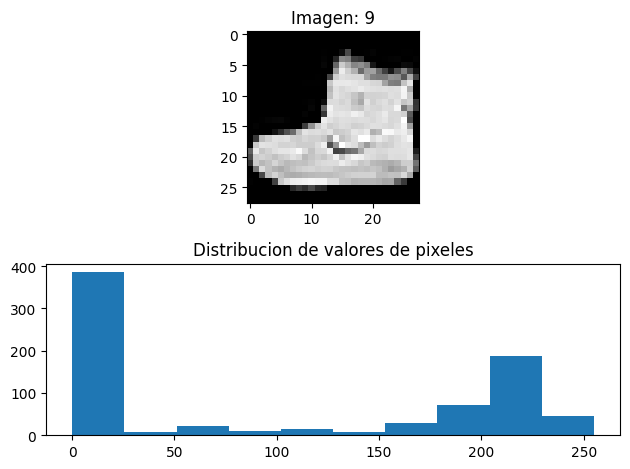

In [8]:
fig = plt.figure()
plt.subplot(2,1,1)
plt.imshow(X_train[0], cmap='gray', interpolation='none')
plt.title("Imagen: {}".format(y_train[0]))
plt.subplot(2,1,2)
plt.hist(X_train[0].reshape(784))
plt.title("Distribucion de valores de pixeles")
plt.tight_layout()
plt.show()

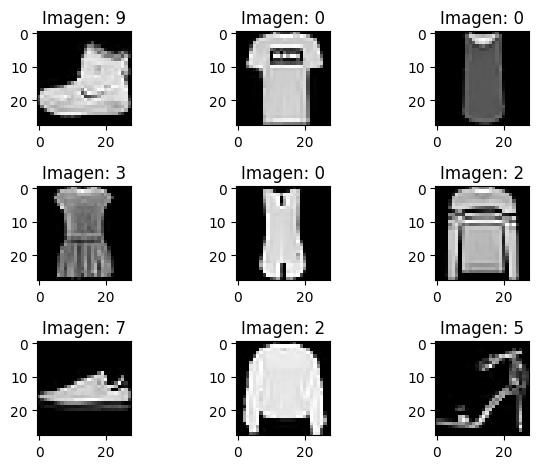

In [9]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.tight_layout()
    plt.imshow(X_train[i], cmap='gray', interpolation='none')
    plt.title("Imagen: {}".format(y_train[i]))

#### Preprocesamiento

Primero escalamos los datos, como los valores van de 0 a 255, basta solamente con dividir por 255

In [10]:
X_train=X_train/255
X_test=X_test/255

Ahora, lo llevaremos de un shape (60000, 28, 28) lo transformaremos en un shape (60000, 28, 28, 1). Esto, porque así lo requiere keras:

In [11]:
X_train=X_train.reshape((60000,28,28,1))
X_test=X_test.reshape((10000,28,28,1))

In [12]:
#X_train




#### Seguimos con la transformación de la respuesta, se debe llevar a un vector

In [13]:
####Ya esta mas abajo, revisar!!

from keras.utils import to_categorical
y_train_v = to_categorical(y_train, 10)
y_test_v = to_categorical(y_test, 10)

#### Diseño de la Arquitectura de la Red

- Input vector: (28,28,1)

- Layer Conv2D: 32 capas con kernel de 3x3 con activacion relu
- Layer MaxPooling: con size de 2x2

- Layer Conv2D: 64 capas con kernel de 3x3 con activacion relu
- Layer MaxPooling: con size de 2x2

- Layer aplanamiento
- Layer Dropout de 0.5
- Layer Denso: con 10 categorías y activacion softmax

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import plot_model

In [16]:
model = Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

In [17]:
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.01),
              metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.utils import to_categorical
y_train=to_categorical(y_train,10)

In [20]:
y_test=to_categorical(y_test,10)

#### Entrenamiento del Modelo

In [21]:
model.fit(X_train,y_train,epochs=5, batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.8125 - loss: 0.5164
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.8457 - loss: 0.4216
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.8530 - loss: 0.4033
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.8542 - loss: 0.3940
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.8562 - loss: 0.3920


#### Métricas de Evaluación

In [22]:
from sklearn.metrics import accuracy_score

In [23]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [24]:
y_pred

array([[2.12836970e-10, 1.13634471e-08, 1.86740081e-08, ...,
        9.18676619e-07, 1.03677138e-08, 9.99971211e-01],
       [2.97010338e-05, 8.47144299e-11, 9.99724507e-01, ...,
        1.59050399e-12, 1.60240621e-09, 1.11908935e-08],
       [2.06800928e-06, 9.99995530e-01, 2.07053617e-07, ...,
        3.67032266e-10, 4.95724748e-07, 4.60286387e-09],
       ...,
       [9.50830303e-10, 1.63221552e-12, 3.10565196e-09, ...,
        6.43828769e-15, 9.99999940e-01, 1.20329399e-14],
       [1.44044145e-06, 9.99941409e-01, 1.91685558e-07, ...,
        1.28658515e-08, 1.65652096e-07, 1.60055379e-06],
       [2.58692610e-03, 7.47268277e-05, 8.43654200e-03, ...,
        6.99509978e-02, 1.13556668e-01, 1.21413171e-02]], dtype=float32)

In [25]:
y_pred_label=np.argmax(y_pred,axis=1)

In [26]:
y_pred_label

array([9, 2, 1, ..., 8, 1, 5])

In [27]:
y_test=np.argmax(y_test,axis=1)

In [28]:
y_test

array([9, 2, 1, ..., 8, 1, 5])

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


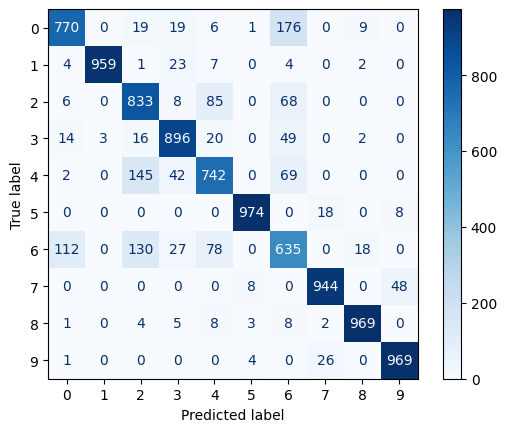

In [30]:
# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred_label)

# Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [31]:
print(classification_report(y_test, y_pred_label))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81      1000
           1       1.00      0.96      0.98      1000
           2       0.73      0.83      0.78      1000
           3       0.88      0.90      0.89      1000
           4       0.78      0.74      0.76      1000
           5       0.98      0.97      0.98      1000
           6       0.63      0.64      0.63      1000
           7       0.95      0.94      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



##Red neuronal densa (ANN)

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# 1. Cargar y normalizar (Escalar entre 0 y 1)
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train_ann = x_train.reshape((60000, 784)).astype('float32') / 255
x_test_ann = x_test.reshape((10000, 784)).astype('float32') / 255

# 2. Definir Red Neuronal Densa (ANN) con Regularización (Dropout)
model_ann = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2), # Técnica de regularización solicitada
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model_ann.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenar ANN
history_ann = model_ann.fit(x_train_ann, y_train, epochs=10,
                            validation_split=0.2, batch_size=128)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8039 - loss: 0.5458 - val_accuracy: 0.8518 - val_loss: 0.4056
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8534 - loss: 0.4006 - val_accuracy: 0.8621 - val_loss: 0.3718
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8701 - loss: 0.3582 - val_accuracy: 0.8699 - val_loss: 0.3515
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8751 - loss: 0.3374 - val_accuracy: 0.8764 - val_loss: 0.3368
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8813 - loss: 0.3199 - val_accuracy: 0.8752 - val_loss: 0.3426
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8862 - loss: 0.3075 - val_accuracy: 0.8830 - val_loss: 0.3234
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8904 - loss: 0.2928 - val_accuracy: 0.8898 - val_loss: 0.3091
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8939 - loss: 0.2801 - val_acc

Red neuronal convolucional CNN

In [33]:
# Preparar datos para CNN (necesitan la dimensión del canal: 28x28x1)
x_train_cnn = x_train.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test_cnn = x_test.reshape((10000, 28, 28, 1)).astype('float32') / 255

# Definir CNN
model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Regularización
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenar CNN
history_cnn = model_cnn.fit(x_train_cnn, y_train, epochs=10,
                            validation_split=0.2, batch_size=128)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.7393 - loss: 0.7307 - val_accuracy: 0.8331 - val_loss: 0.4532
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.8334 - loss: 0.4641 - val_accuracy: 0.8633 - val_loss: 0.3757
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 101ms/step - accuracy: 0.8554 - loss: 0.4056 - val_accuracy: 0.8677 - val_loss: 0.3575
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.8678 - loss: 0.3698 - val_accuracy: 0.8802 - val_loss: 0.3220
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 95ms/step - accuracy: 0.8765 - loss: 0.3439 - val_accuracy: 0.8886 - val_loss: 0.3101
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.8853 - loss: 0.3203 - val_accuracy: 0.8905 - val_loss: 0.2966
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.8917 - loss: 0.2998 - val_accuracy: 0.8967 - val_loss: 0.2785
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.8951 - loss: 0.2

In [34]:
from tensorflow.keras.preprocessing import image

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def cargar_y_preprocesar_imagen(ruta_imagen):
    """
    Carga una imagen externa y la adapta al formato de Fashion-MNIST:
    - Escala de grises
    - Tamaño 28x28
    - Normalización a rango [0, 1]
    - Dimensiones (1, 28, 28, 1)
    """
    img = image.load_img(ruta_imagen, color_mode="grayscale", target_size=(28, 28))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = img_array.reshape((1, 28, 28, 1))
    return img_array, img


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Clase predicha: 8 - Bag
Probabilidad: 0.9804


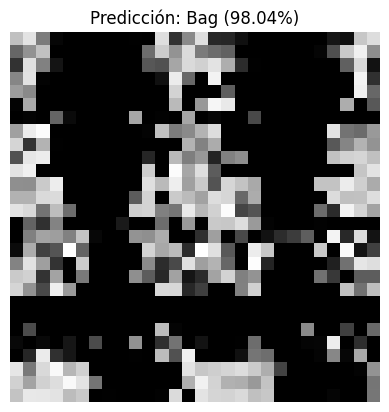

In [35]:
# Ruta de ejemplo: sube una imagen a Colab y coloca el path aquí
ruta_imagen = "fashion-mnist-sprite.png"  # Cambiar por el nombre real del archivo

img_array, img_original = cargar_y_preprocesar_imagen(ruta_imagen)

# Predicción con el modelo convolutivo entrenado
predicciones = model_cnn.predict(img_array)
clase_predicha = np.argmax(predicciones[0])
probabilidad = np.max(predicciones[0])

print(f"Clase predicha: {clase_predicha} - {class_names[clase_predicha]}")
print(f"Probabilidad: {probabilidad:.4f}")

plt.imshow(img_original, cmap="gray")
plt.title(f"Predicción: {class_names[clase_predicha]} ({probabilidad:.2%})")
plt.axis("off")
plt.show()


Metricas

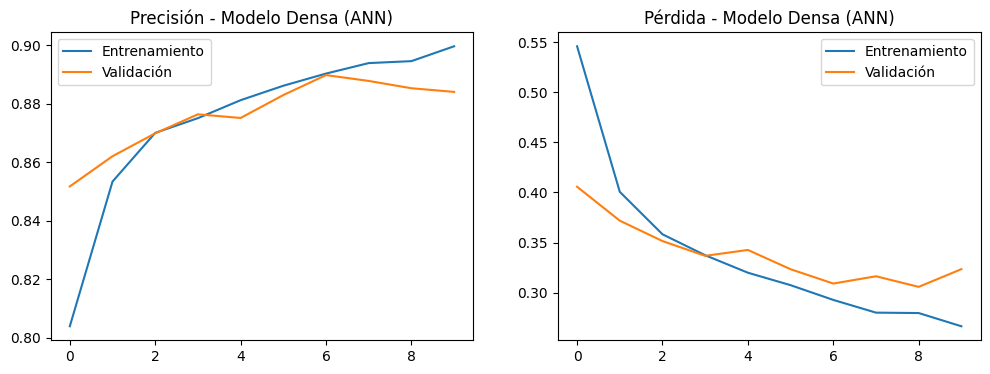

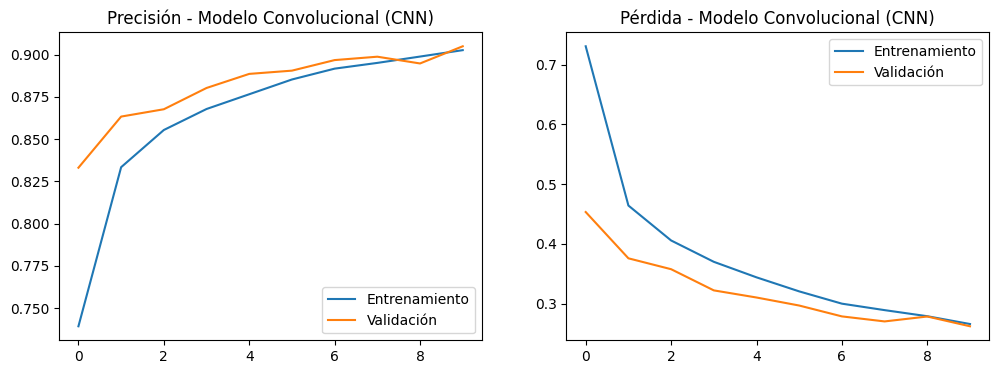

In [36]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Gráfico de Precisión
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'Precisión - {title}')
    plt.legend()

    # Gráfico de Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'Pérdida - {title}')
    plt.legend()
    plt.show()

# Ejecutar visualización
plot_history(history_ann, "Modelo Densa (ANN)")
plot_history(history_cnn, "Modelo Convolucional (CNN)")

### Comparación de desempeño: red densa vs CNN

A continuación se comparan las métricas principales de la red neuronal densa y la red convolutiva sobre el conjunto de test. Esto permite evaluar la mejora que aporta la CNN al aprovechar la estructura espacial de las imágenes.


In [37]:
loss_dense, acc_dense = model_ann.evaluate(x_test_ann, y_test, verbose=0)
loss_cnn, acc_cnn = model_cnn.evaluate(x_test_cnn, y_test, verbose=0)

print(f"Red densa - Loss: {loss_dense:.4f}, Accuracy: {acc_dense:.4f}")
print(f"CNN       - Loss: {loss_cnn:.4f}, Accuracy: {acc_cnn:.4f}")

mejora = (acc_cnn - acc_dense) * 100
print(f"Mejora de accuracy de la CNN respecto a la densa: {mejora:.2f} puntos porcentuales")

Red densa - Loss: 0.3465, Accuracy: 0.8766
CNN       - Loss: 0.2759, Accuracy: 0.8988
Mejora de accuracy de la CNN respecto a la densa: 2.22 puntos porcentuales
